<a href="https://colab.research.google.com/github/abhinav-sharma15/marketing-measurement-system/blob/main/notebooks/02_geo_lift_synthetic_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

2. Create synthetic geo dataset

This mirrors the Week 3 geo lift dataset so we can compare DiD and synthetic control later.

In [2]:
n_geos = 24
n_weeks = 12

geos = [f"Geo_{i+1}" for i in range(n_geos)]
weeks = np.arange(1, n_weeks + 1)

df = pd.MultiIndex.from_product(
    [geos, weeks],
    names=["geo", "week"]
).to_frame(index=False)

df.head()

,geo,week
0,Geo_1,1
1,Geo_1,2
2,Geo_1,3
3,Geo_1,4
4,Geo_1,5


3. Assign treatment and post-period

In [3]:
treated_geos = np.random.choice(
    geos,
    size=n_geos // 2,
    replace=False
)

df["treatment"] = df["geo"].isin(treated_geos).astype(int)
df["post_period"] = (df["week"] >= 7).astype(int)

df.head()

,geo,week,treatment,post_period
0,Geo_1,1,1,0
1,Geo_1,2,1,0
2,Geo_1,3,1,0
3,Geo_1,4,1,0
4,Geo_1,5,1,0


In [4]:
df.groupby("treatment")["geo"].nunique()

,geo
treatment,
0,12
1,12


4. Simulate revenue components

We simulate revenue using:

* geo baseline demand
* common time trend
* seasonality
* random noise
* treatment effect after week 7



In [5]:
geo_baseline = {
    geo: np.random.normal(1000, 150)
    for geo in geos
}

df["geo_baseline"] = df["geo"].map(geo_baseline)

df["time_trend"] = df["week"] * 20

df["seasonality"] = (
    80 * np.sin(2 * np.pi * df["week"] / 12)
)

df["noise"] = np.random.normal(0, 80, size=len(df))

true_treatment_effect = 180

df["treatment_effect"] = (
    df["treatment"]
    * df["post_period"]
    * true_treatment_effect
)

df["revenue"] = (
    df["geo_baseline"]
    + df["time_trend"]
    + df["seasonality"]
    + df["treatment_effect"]
    + df["noise"]
)

df.head()

,geo,week,treatment,post_period,geo_baseline,time_trend,seasonality,noise,treatment_effect,revenue
0,Geo_1,1,1,0,1036.294341,20,40.000000,16.709088,0,1113.003428
1,Geo_1,2,1,0,1036.294341,40,69.282032,-156.773610,0,988.802763
2,Geo_1,3,1,0,1036.294341,60,80.000000,-106.254884,0,1070.039457
3,Geo_1,4,1,0,1036.294341,80,69.282032,15.748899,0,1201.325272
4,Geo_1,5,1,0,1036.294341,100,40.000000,59.077326,0,1235.371667


5. Create weekly treatment/control averages

Synthetic control usually works at the unit level, but for this first version we’ll build a synthetic control for the average treated group.

In [6]:
weekly_avg = (
    df.groupby(["week", "treatment"])["revenue"]
    .mean()
    .reset_index()
)

weekly_avg.head()

,week,treatment,revenue
0,1,0,1010.619249
1,1,1,997.823405
2,2,0,1050.560613
3,2,1,1007.049491
4,3,0,1102.673160


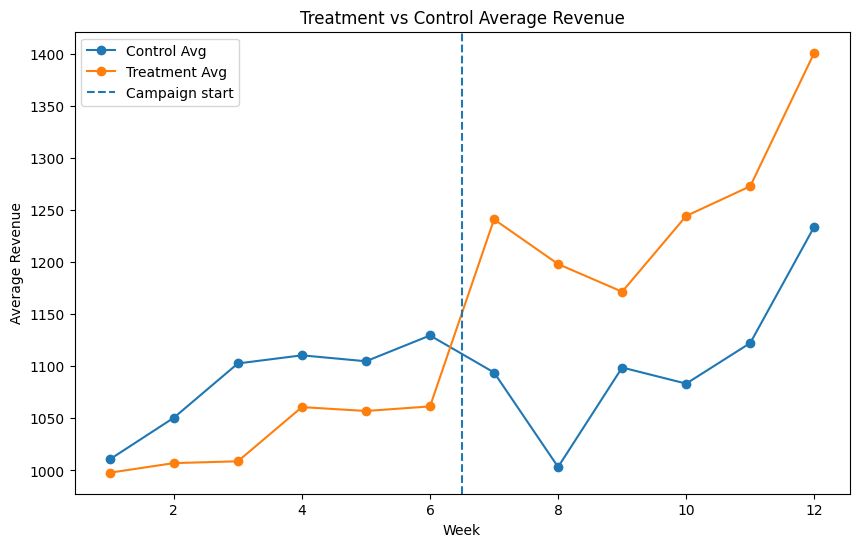

In [7]:
plt.figure(figsize=(10, 6))

for treatment_value, label in [(0, "Control Avg"), (1, "Treatment Avg")]:
    subset = weekly_avg[weekly_avg["treatment"] == treatment_value]
    plt.plot(
        subset["week"],
        subset["revenue"],
        marker="o",
        label=label
    )

plt.axvline(6.5, linestyle="--", label="Campaign start")
plt.title("Treatment vs Control Average Revenue")
plt.xlabel("Week")
plt.ylabel("Average Revenue")
plt.legend()
plt.show()

## Interpretation

This chart compares average revenue for treatment and control geos over time.

Treatment starts in week 7.

Before building synthetic control, we want to visually inspect whether:
- treatment and control move similarly before week 7
- post-period divergence appears after the campaign begins

However, synthetic control will go beyond a simple average control group by constructing a weighted combination of individual control geos.

6. Separate pre-period and post-period

In [8]:
pre_period = df[df["week"] < 7].copy()
post_period = df[df["week"] >= 7].copy()

pre_period["week"].unique(), post_period["week"].unique()

(array([1, 2, 3, 4, 5, 6]), array([ 7,  8,  9, 10, 11, 12]))

## Pre/Post Split

The pre-period is used to build the synthetic control.

The post-period is used to evaluate whether the treatment group diverged from its synthetic counterfactual after the campaign started.

Important:
The synthetic control weights must be learned only from the pre-period.

7. Create treated average pre-period vector

This is the outcome we want the synthetic control to match before treatment.

In [9]:
treated_avg_pre = (
    pre_period[pre_period["treatment"] == 1]
    .groupby("week")["revenue"]
    .mean()
)

treated_avg_pre

,revenue
week,
1,997.823405
2,1007.049491
3,1008.783354
4,1060.788383
5,1057.069138
6,1061.447058


In [10]:
treated_avg_pre.shape

(6,)

8. Create control geo pre-period matrix

Rows = weeks
Columns = individual control geos
Values = revenue

In [11]:
control_pre_matrix = (
    pre_period[pre_period["treatment"] == 0]
    .pivot(
        index="week",
        columns="geo",
        values="revenue"
    )
)

control_pre_matrix.head()

geo,Geo_11,Geo_15,Geo_16,Geo_18,Geo_20,Geo_21,Geo_23,Geo_24,Geo_4,Geo_5,Geo_7,Geo_8
week,,,,,,,,,,,,
1,1219.391192,777.137414,1054.528686,952.844278,1317.636276,1073.900192,1117.062136,942.906760,972.790787,843.395844,944.400420,911.437001
2,1157.317897,861.606992,1146.691247,1056.349055,1287.301105,1059.240098,1187.849286,991.236256,1150.110395,917.216801,967.122748,824.685481
3,1054.824951,1008.553785,1157.525619,1136.644920,1548.434632,1143.559583,1323.165225,1061.311757,846.077262,1061.307501,850.294691,1040.377990
4,1211.935552,1017.735872,1212.186666,1174.788385,1312.712450,1116.432361,1321.493390,967.835792,1130.691103,1023.657453,1010.957311,825.288392
5,1072.154697,1008.554778,1381.527388,1000.222225,1382.638169,1147.056804,1261.709609,1011.429690,1062.620636,945.694516,1008.614805,975.103012


In [12]:
control_pre_matrix.shape

(6, 12)

## Synthetic Control Input Structure

For synthetic control, we need:

- a treated outcome vector
- a matrix of possible control geos

The algorithm will find weights across the control geo columns so that their weighted average best matches the treated average in the pre-period.

9. Create full-period control matrix

Later we’ll use the same control weights across the full period.

In [13]:
control_full_matrix = (
    df[df["treatment"] == 0]
    .pivot(
        index="week",
        columns="geo",
        values="revenue"
    )
)

control_full_matrix.head()

geo,Geo_11,Geo_15,Geo_16,Geo_18,Geo_20,Geo_21,Geo_23,Geo_24,Geo_4,Geo_5,Geo_7,Geo_8
week,,,,,,,,,,,,
1,1219.391192,777.137414,1054.528686,952.844278,1317.636276,1073.900192,1117.062136,942.906760,972.790787,843.395844,944.400420,911.437001
2,1157.317897,861.606992,1146.691247,1056.349055,1287.301105,1059.240098,1187.849286,991.236256,1150.110395,917.216801,967.122748,824.685481
3,1054.824951,1008.553785,1157.525619,1136.644920,1548.434632,1143.559583,1323.165225,1061.311757,846.077262,1061.307501,850.294691,1040.377990
4,1211.935552,1017.735872,1212.186666,1174.788385,1312.712450,1116.432361,1321.493390,967.835792,1130.691103,1023.657453,1010.957311,825.288392
5,1072.154697,1008.554778,1381.527388,1000.222225,1382.638169,1147.056804,1261.709609,1011.429690,1062.620636,945.694516,1008.614805,975.103012


10. Create full-period treated actual series

In [14]:
treated_actual = (
    df[df["treatment"] == 1]
    .groupby("week")["revenue"]
    .mean()
)

treated_actual

,revenue
week,
1,997.823405
2,1007.049491
3,1008.783354
4,1060.788383
5,1057.069138
6,1061.447058
7,1240.945595
8,1198.040167
9,1171.505699


11. Visualize individual control geos vs treated average

This is useful because synthetic control is built from individual control geos, not only the average control line.

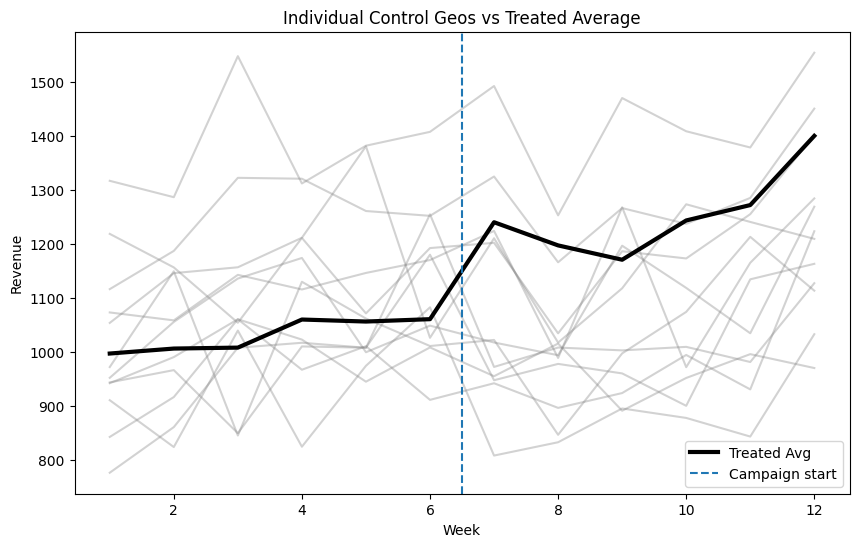

In [15]:
plt.figure(figsize=(10, 6))

for geo in control_full_matrix.columns:
    plt.plot(
        control_full_matrix.index,
        control_full_matrix[geo],
        color="gray",
        alpha=0.35
    )

plt.plot(
    treated_actual.index,
    treated_actual.values,
    color="black",
    linewidth=3,
    label="Treated Avg"
)

plt.axvline(6.5, linestyle="--", label="Campaign start")

plt.title("Individual Control Geos vs Treated Average")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.legend()
plt.show()

## Why This Plot Matters

This plot shows whether the available control geos provide enough variation to construct a credible synthetic control.

If the treated average sits far outside the range of control geos before treatment, synthetic control may struggle to find a good match.

A good donor pool should contain control geos that can reasonably reproduce the treated group's pre-period behavior.

12. Save prepared data objects conceptually

You don’t need to save files yet, but at this point you have the key inputs:

In [16]:
print("Treated pre-period vector shape:", treated_avg_pre.shape)
print("Control pre-period matrix shape:", control_pre_matrix.shape)
print("Control full-period matrix shape:", control_full_matrix.shape)
print("Treated actual full-period shape:", treated_actual.shape)

Treated pre-period vector shape: (6,)
Control pre-period matrix shape: (6, 12)
Control full-period matrix shape: (12, 12)
Treated actual full-period shape: (12,)


## Day 2 Summary

Today we prepared the data needed for synthetic control.

Key objects created:

- `treated_avg_pre`: treated group average revenue before campaign
- `control_pre_matrix`: control geo revenue before campaign
- `control_full_matrix`: control geo revenue across all weeks
- `treated_actual`: treated group average revenue across all weeks

Next, we will estimate synthetic control weights that best match the treatment group during the pre-period.

In [17]:
from scipy.optimize import minimize

14. Define the objective function

The objective function measures how far the synthetic control is from the treated group during the pre-period.

In [18]:
def objective(weights, control_matrix, treated_vector):
    synthetic = control_matrix.values @ weights
    error = treated_vector.values - synthetic
    return np.mean(error ** 2)

## Objective Function

The goal is to find weights for control geos that minimize the difference between:

- treated group revenue before the campaign
- weighted control geo revenue before the campaign

This means the synthetic control is trained only on the pre-period.

The lower the objective value, the better the pre-period fit.

15. Set up weights, constraints, and bounds

Synthetic control weights should usually satisfy two rules:

* each weight is between 0 and 1
* all weights sum to 1

In [19]:
n_controls = control_pre_matrix.shape[1]

initial_weights = np.ones(n_controls) / n_controls

constraints = {
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
}

bounds = [(0, 1) for _ in range(n_controls)]

## Weight Constraints

The weights are constrained so that:

- no control geo receives a negative weight
- total weights sum to 1

This makes the synthetic control a weighted average of real control geos, which helps keep the counterfactual interpretable.

16. Optimize the weights

In [20]:
result = minimize(
    objective,
    initial_weights,
    args=(control_pre_matrix, treated_avg_pre),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

print("Optimization success:", result.success)
print("Objective value:", result.fun)

Optimization success: True
Objective value: 3375.320340131501


In [22]:
if not result.success:
    print(result.message)

17. Extract and inspect weights

In [23]:
weights = result.x

weights_df = pd.DataFrame({
    "geo": control_pre_matrix.columns,
    "weight": weights
}).sort_values("weight", ascending=False)

weights_df

,geo,weight
11,Geo_8,0.083333
4,Geo_20,0.083333
6,Geo_23,0.083333
2,Geo_16,0.083333
0,Geo_11,0.083333
5,Geo_21,0.083333
3,Geo_18,0.083333
1,Geo_15,0.083333
7,Geo_24,0.083333
8,Geo_4,0.083333


In [24]:
weights_df[weights_df["weight"] > 0.01]

,geo,weight
11,Geo_8,0.083333
4,Geo_20,0.083333
6,Geo_23,0.083333
2,Geo_16,0.083333
0,Geo_11,0.083333
5,Geo_21,0.083333
3,Geo_18,0.083333
1,Geo_15,0.083333
7,Geo_24,0.083333
8,Geo_4,0.083333


## Synthetic Control Weights

The weights show which control geos were used to construct the synthetic control.

A control geo with a high weight was useful for matching the treated group during the pre-period.

A control geo with a near-zero weight contributed little to the counterfactual.

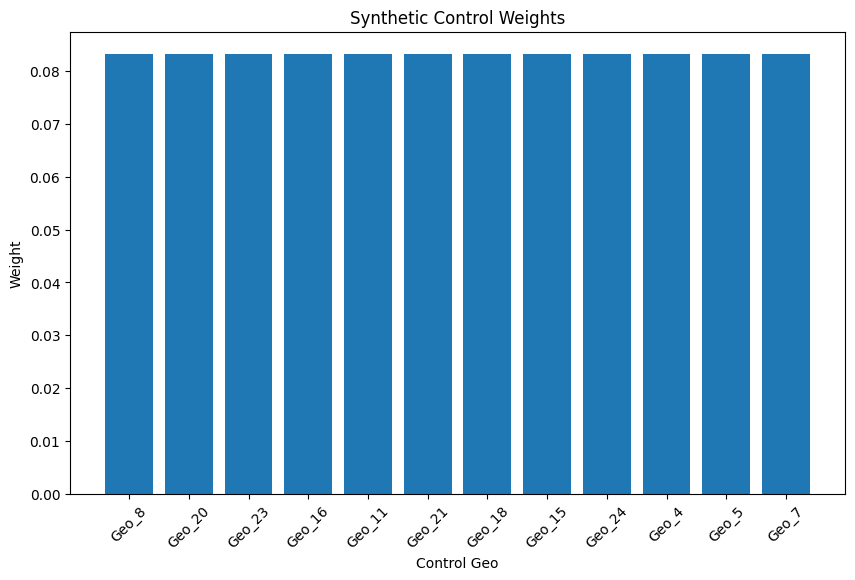

In [25]:
weights_plot = weights_df[weights_df["weight"] > 0.01].copy()

plt.figure(figsize=(10, 6))
plt.bar(weights_plot["geo"], weights_plot["weight"])
plt.title("Synthetic Control Weights")
plt.xlabel("Control Geo")
plt.ylabel("Weight")
plt.xticks(rotation=45)
plt.show()

## Weight Interpretation

The synthetic control should ideally be built from a reasonable mix of comparable control geos.

If one control geo receives nearly all the weight, the result may be sensitive to that single region.

That is not automatically wrong, but it should be investigated.

19. Build pre-period synthetic control

Now use the learned weights to create the synthetic control for the pre-period.

In [26]:
synthetic_pre = control_pre_matrix.values @ weights

pre_fit_df = pd.DataFrame({
    "week": control_pre_matrix.index,
    "treated_actual": treated_avg_pre.values,
    "synthetic_control": synthetic_pre
})

pre_fit_df["gap"] = (
    pre_fit_df["treated_actual"]
    - pre_fit_df["synthetic_control"]
)

pre_fit_df

,week,treated_actual,synthetic_control,gap
0,1,997.823405,1010.619249,-12.795843
1,2,1007.049491,1050.560609,-43.511119
2,3,1008.783354,1102.673161,-93.889807
3,4,1060.788383,1110.476222,-49.687839
4,5,1057.069138,1104.777193,-47.708055
5,6,1061.447058,1129.525948,-68.078889


20. Plot pre-period fit

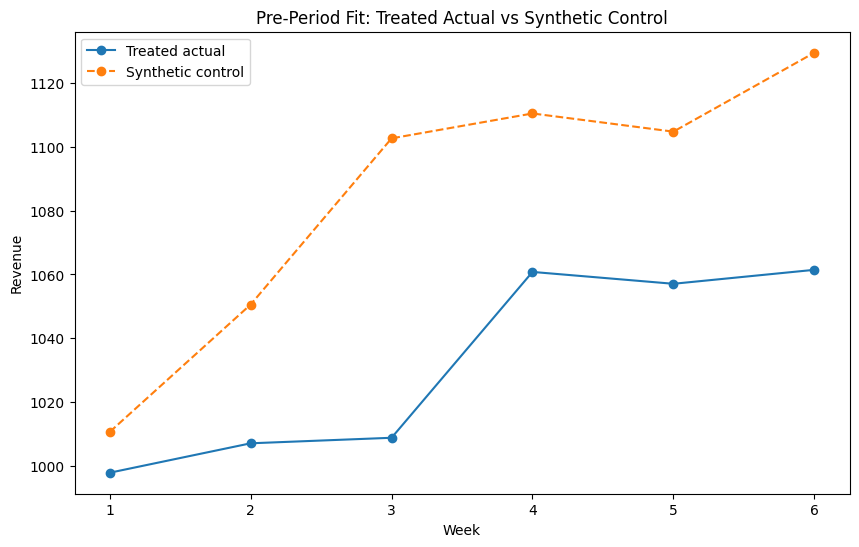

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    pre_fit_df["week"],
    pre_fit_df["treated_actual"],
    marker="o",
    label="Treated actual"
)

plt.plot(
    pre_fit_df["week"],
    pre_fit_df["synthetic_control"],
    marker="o",
    linestyle="--",
    label="Synthetic control"
)

plt.title("Pre-Period Fit: Treated Actual vs Synthetic Control")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.legend()
plt.show()

## Pre-Period Fit

This plot shows whether the synthetic control matches the treated group before the campaign.

A close match supports the credibility of the synthetic control.

If the lines do not track closely before treatment, the synthetic control may not be a reliable counterfactual.

21. Calculate pre-period fit quality

In [28]:
pre_rmse = np.sqrt(
    np.mean(
        (pre_fit_df["treated_actual"] - pre_fit_df["synthetic_control"]) ** 2
    )
)

pre_mape = np.mean(
    np.abs(
        (pre_fit_df["treated_actual"] - pre_fit_df["synthetic_control"])
        / pre_fit_df["treated_actual"]
    )
)

print(f"Pre-period RMSE: {pre_rmse:.2f}")
print(f"Pre-period MAPE: {pre_mape:.2%}")

Pre-period RMSE: 58.10
Pre-period MAPE: 5.09%


## Fit Diagnostics

RMSE measures the average size of pre-period prediction errors.

MAPE expresses the error as a percentage of actual treated revenue.

Lower values indicate a better pre-period fit.

If pre-period error is large, post-period lift estimates should be interpreted cautiously.

22. Compare against simple average control

This helps show why synthetic control can improve on basic DiD-style comparisons.

In [29]:
simple_control_pre = (
    pre_period[pre_period["treatment"] == 0]
    .groupby("week")["revenue"]
    .mean()
)

comparison_pre = pd.DataFrame({
    "week": treated_avg_pre.index,
    "treated_actual": treated_avg_pre.values,
    "simple_control_avg": simple_control_pre.values,
    "synthetic_control": synthetic_pre
})

comparison_pre["simple_control_error"] = (
    comparison_pre["treated_actual"]
    - comparison_pre["simple_control_avg"]
)

comparison_pre["synthetic_control_error"] = (
    comparison_pre["treated_actual"]
    - comparison_pre["synthetic_control"]
)

comparison_pre

,week,treated_actual,simple_control_avg,synthetic_control,simple_control_error,synthetic_control_error
0,1,997.823405,1010.619249,1010.619249,-12.795843,-12.795843
1,2,1007.049491,1050.560613,1050.560609,-43.511123,-43.511119
2,3,1008.783354,1102.673160,1102.673161,-93.889806,-93.889807
3,4,1060.788383,1110.476227,1110.476222,-49.687845,-49.687839
4,5,1057.069138,1104.777194,1104.777193,-47.708056,-47.708055
5,6,1061.447058,1129.525946,1129.525948,-68.078888,-68.078889


In [30]:
simple_rmse = np.sqrt(
    np.mean(comparison_pre["simple_control_error"] ** 2)
)

synthetic_rmse = np.sqrt(
    np.mean(comparison_pre["synthetic_control_error"] ** 2)
)

print(f"Simple control pre-period RMSE: {simple_rmse:.2f}")
print(f"Synthetic control pre-period RMSE: {synthetic_rmse:.2f}")

Simple control pre-period RMSE: 58.10
Synthetic control pre-period RMSE: 58.10


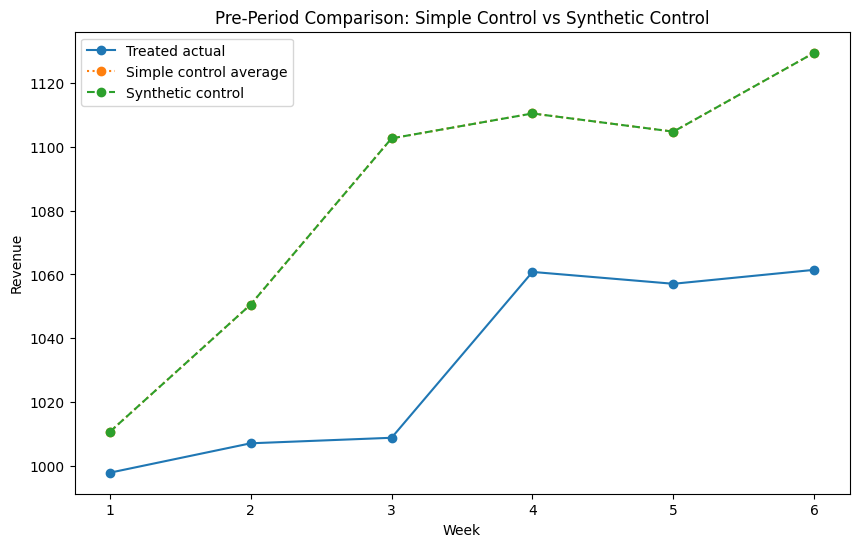

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    comparison_pre["week"],
    comparison_pre["treated_actual"],
    marker="o",
    label="Treated actual"
)

plt.plot(
    comparison_pre["week"],
    comparison_pre["simple_control_avg"],
    marker="o",
    linestyle=":",
    label="Simple control average"
)

plt.plot(
    comparison_pre["week"],
    comparison_pre["synthetic_control"],
    marker="o",
    linestyle="--",
    label="Synthetic control"
)

plt.title("Pre-Period Comparison: Simple Control vs Synthetic Control")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.legend()
plt.show()

## Simple Control vs Synthetic Control

A simple control average gives equal weight to all control geos.

Synthetic control gives higher weight to the control geos that best match the treated group before treatment.

If synthetic control has lower pre-period error, it provides a more tailored counterfactual than the simple average control group.

# Day 3 Summary

Today we estimated synthetic control weights.

Key outputs:

- optimized weights across control geos
- pre-period synthetic control series
- pre-period fit diagnostics
- comparison against simple average control

The synthetic control is only credible if it closely matches the treated group before the campaign.

Next, we will apply these weights to the full time period and estimate post-campaign incremental lift.